In [1]:
# String to test
epsilon = [0, 1, 1, 0, 1, 1, 0, 1, 0, 1]

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaincc
    
def read_1_mio_bits_and_eval(file, draw=True):
    print(f"Reading file {file}")
    with open(file, "r") as f:
        contents = f.read()
        
    # Get individual lines
    contents = contents.split(" ")

    # Get bits
    epsilon = []

    for c in contents:
        c = c.replace("\n", "")
        c = c.strip()
        if len(c) == 0:
            continue
        for bit in c:
            epsilon.append(int(bit))
            
    # limit epsilon
    epsilon = epsilon[:1000000]
    #epsilon = epsilon[:100]
    
    # Change representation (Step 1)
    X = []

    for e in epsilon:
        X.append((2*e) - 1)
        
    # Compute partial sums ( Step 2 + 3)

    S = [0] # Already attach leading zero (see step 3)

    sum = 0
    for i in range(len(X)):
        sum += X[i]
        S.append(sum)
        
    # Attach trailing zero (step 3)
    S.append(0)
    
    # Draw random walk

    if draw:
        # Set axes
        x = np.arange(0, len(S), 1)
        y = S

        # Plot
        plt.figure()
        plt.axhline(y=1, c="r")
        plt.axhline(y=2, c="r")
        plt.axhline(y=3, c="r")
        plt.axhline(y=4, c="r")
        plt.axhline(y=-1, c="r")
        plt.axhline(y=-2, c="r")
        plt.axhline(y=-3, c="r")
        plt.axhline(y=-4, c="r")
        plt.axhline(y=0, c="k")
        plt.plot(x, y)
        plt.savefig("../figures/random_excursion.pdf")
    
    # Compute amount of cycles: Step 4
    J = S.count(0) - 1 # Leading zero

    # Get constraint
    constraint = max(0.005*(len(epsilon)**0.5), 500)

    if J < constraint:
        print(f"J is < 500: {J}")
        print(f"Mean: {np.mean(np.array(epsilon))}")
        
    # Get cycles (step 4)
    cycles_mask = (np.array(S) == 0)
    cycles_positions = []
    for i in range(len(cycles_mask)):
        if cycles_mask[i] == True:
            cycles_positions.append(i)
            
    # Get individual cycles (step 4)
    cycles = []
    for i in range(1, len(cycles_positions)):
        cycles.append(S[cycles_positions[i-1]:cycles_positions[i]+1])
        
    # Create frequency state-cycle matrix (Step 5)
    frequency_matrix = []
    considered = 0

    for cycle in cycles:
        states = []
        cycle = np.array(cycle)
        
        # Get state count per cycle
        for i in range(-4, 5):
            if i == 0:
                continue
            state_count = int((cycle == i).sum())
            states.append(state_count)
            considered += state_count
            
        frequency_matrix.append(states)
        
    print(f"Considered percentage {considered / len(epsilon) *100}")
    
    # Transform matrix for step 6
    frequency_matrix = np.array(frequency_matrix).T
    
    # Get number of states/cycle
    states_matrix = []

    for i in range(6):
        state_count = []
        for state in frequency_matrix:
            count = 0
            if i == 5:
                count = int(((state) >= i).sum())
            else:
                count = int(((state) == i).sum())
            state_count.append(count)
        states_matrix.append(state_count)

    states_matrix = np.array(states_matrix).T
    
    # Define population distributions
    distributions = np.array([
        [0.5000000000, 0.25000000000, 0.12500000000, 0.06250000000, 0.03125000000, 0.0312500000],
        [0.7500000000, 0.06250000000, 0.04687500000, 0.03515625000, 0.02636718750, 0.0791015625],
        [0.8333333333, 0.02777777778, 0.02314814815, 0.01929012346, 0.01607510288, 0.0803755143],
        [0.8750000000, 0.01562500000, 0.01367187500, 0.01196289063, 0.01046752930, 0.073272705]
    ])
    
    # Create a matrix that has equal indicies with states matrix
    pi = np.array([
        distributions[3],
        distributions[2],
        distributions[1],
        distributions[0],
        distributions[0],
        distributions[1],
        distributions[2],
        distributions[3],
    ])
    
    # Compute test statistics
    statistics = []
    for i in range(8): # iterate over states
        statistic = 0
        # iterate over cycles
        for j in range(6):
            observation = states_matrix[i][j]
            expectation = pi[i][j]
            intermediate = ((observation - J * expectation)**2) / (J* expectation)
            statistic += intermediate
        statistics.append(statistic)
        
    # Compute p-values

    pvalues = []
    for s in statistics:
        pvalues.append(gammaincc(2.5, s / 2.0))
    print(pvalues)
    return pvalues

Reading file ../data/pinecone/001.txt
Considered percentage 0.5815
[np.float64(0.2697570992412562), np.float64(0.7508918442108873), np.float64(0.6125381120750742), np.float64(0.7735875248587507), np.float64(0.5549832000512438), np.float64(0.8368401846661795), np.float64(0.5111464066671659), np.float64(0.6416217021432485)]


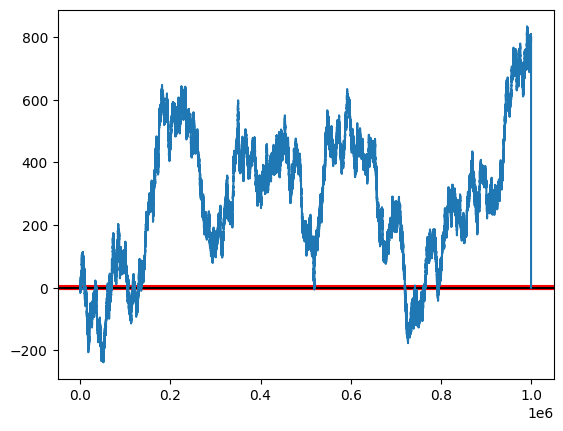

In [11]:
pvalues = []

for i in range(1, 2):
    pvalues.extend(read_1_mio_bits_and_eval(f"../data/pinecone/{i:03d}.txt", draw=True))

(array([188., 169., 190., 189., 211., 202., 205., 227., 250., 169.]),
 array([1.41944398e-04, 1.00125643e-01, 2.00109343e-01, 3.00093042e-01,
        4.00076741e-01, 5.00060440e-01, 6.00044139e-01, 7.00027838e-01,
        8.00011537e-01, 8.99995236e-01, 9.99978935e-01]),
 <BarContainer object of 10 artists>)

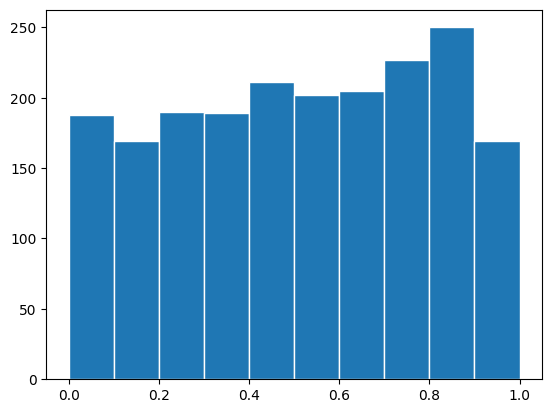

In [92]:
plt.hist(pvalues, bins=10, edgecolor="white")

In [69]:

## testing


In [71]:
def pi_0(x):
    return 1 - (1 / (2 * abs(x)))

In [75]:
for i in range(1, 8):
    print(f"x = {i}: {pi_0(i):.4f}")

x = 1: 0.5000
x = 2: 0.7500
x = 3: 0.8333
x = 4: 0.8750
x = 5: 0.9000
x = 6: 0.9167
x = 7: 0.9286


In [76]:
def pi_k(k, x):
    return (1 / (4 * (x**2))) * (pi_0(x))**(k-1)

In [79]:
for i in range(1, 8):
    for j in range(1, 10):
        print(f"x = {i}, k = {j}: {pi_k(j, i):.4f}")
        
    print("="* 20)

x = 1, k = 1: 0.2500
x = 1, k = 2: 0.1250
x = 1, k = 3: 0.0625
x = 1, k = 4: 0.0312
x = 1, k = 5: 0.0156
x = 1, k = 6: 0.0078
x = 1, k = 7: 0.0039
x = 1, k = 8: 0.0020
x = 1, k = 9: 0.0010
x = 2, k = 1: 0.0625
x = 2, k = 2: 0.0469
x = 2, k = 3: 0.0352
x = 2, k = 4: 0.0264
x = 2, k = 5: 0.0198
x = 2, k = 6: 0.0148
x = 2, k = 7: 0.0111
x = 2, k = 8: 0.0083
x = 2, k = 9: 0.0063
x = 3, k = 1: 0.0278
x = 3, k = 2: 0.0231
x = 3, k = 3: 0.0193
x = 3, k = 4: 0.0161
x = 3, k = 5: 0.0134
x = 3, k = 6: 0.0112
x = 3, k = 7: 0.0093
x = 3, k = 8: 0.0078
x = 3, k = 9: 0.0065
x = 4, k = 1: 0.0156
x = 4, k = 2: 0.0137
x = 4, k = 3: 0.0120
x = 4, k = 4: 0.0105
x = 4, k = 5: 0.0092
x = 4, k = 6: 0.0080
x = 4, k = 7: 0.0070
x = 4, k = 8: 0.0061
x = 4, k = 9: 0.0054
x = 5, k = 1: 0.0100
x = 5, k = 2: 0.0090
x = 5, k = 3: 0.0081
x = 5, k = 4: 0.0073
x = 5, k = 5: 0.0066
x = 5, k = 6: 0.0059
x = 5, k = 7: 0.0053
x = 5, k = 8: 0.0048
x = 5, k = 9: 0.0043
x = 6, k = 1: 0.0069
x = 6, k = 2: 0.0064
x = 6, k = 3:

In [93]:
    distributions = np.array([
        [0.5000000000, 0.25000000000, 0.12500000000, 0.06250000000, 0.03125000000, 0.0312500000],
        [0.7500000000, 0.06250000000, 0.04687500000, 0.03515625000, 0.02636718750, 0.0791015625],
        [0.8333333333, 0.02777777778, 0.02314814815, 0.01929012346, 0.01607510288, 0.0803755143],
        [0.8750000000, 0.01562500000, 0.01367187500, 0.01196289063, 0.01046752930, 0.073272705]
    ])

In [94]:
distributions

array([[0.5       , 0.25      , 0.125     , 0.0625    , 0.03125   ,
        0.03125   ],
       [0.75      , 0.0625    , 0.046875  , 0.03515625, 0.02636719,
        0.07910156],
       [0.83333333, 0.02777778, 0.02314815, 0.01929012, 0.0160751 ,
        0.08037551],
       [0.875     , 0.015625  , 0.01367188, 0.01196289, 0.01046753,
        0.0732727 ]])

In [137]:
def pi_final(x, k=5):
    return 1 / (2 * abs(x)) * ((pi_0(x))**(k-1))

In [161]:
def generate_frequencies(x, max_k=5):
    dist = []
    dist.append(pi_0(x))
    for i in range(1, max_k):
        dist.append(pi_k(i, x))
    dist.append(pi_final(x, k=i+1))
    return dist

In [143]:
np.sum(dist)

np.float64(1.0)

In [164]:
generate_frequencies(1)

[0.5, 0.25, 0.125, 0.0625, 0.03125, 0.03125]

In [169]:
def generate_distributions(max_x=7):
    dists = []
    for i in range(1, max_x+1):
        dists.append(generate_frequencies(i))
    return dists

In [170]:
generate_distributions()

[[0.5, 0.25, 0.125, 0.0625, 0.03125, 0.03125],
 [0.75, 0.0625, 0.046875, 0.03515625, 0.0263671875, 0.0791015625],
 [0.8333333333333334,
  0.027777777777777776,
  0.023148148148148147,
  0.019290123456790126,
  0.01607510288065844,
  0.08037551440329219],
 [0.875,
  0.015625,
  0.013671875,
  0.011962890625,
  0.010467529296875,
  0.073272705078125],
 [0.9,
  0.01,
  0.009000000000000001,
  0.008100000000000001,
  0.007290000000000001,
  0.06561],
 [0.9166666666666666,
  0.006944444444444444,
  0.00636574074074074,
  0.005835262345679011,
  0.005348990483539094,
  0.05883889531893003],
 [0.9285714285714286,
  0.00510204081632653,
  0.004737609329446064,
  0.004399208663057059,
  0.004084979472838698,
  0.05310473314690308]]